# Day 7 GPU 강제 실행 수정본 v2

이 노트북은 **CPU fallback을 제거하고 CUDA GPU 사용을 강제**합니다.

이번 v2 수정 내용:
- `tokenizer is not defined` 오류 방지
- 단독 테스트용 모델 메모리 정리 셀 위치 수정
- 단독 생성 테스트가 실행 전 모델 존재 여부를 확인하고 없으면 자동 로드
- 로컬 모델 경로 `D:\hf_models\qwen2.5-3b-instruct`가 있으면 우선 사용
- 서버도 로컬 모델 경로를 우선 사용


모델 배포 개론 07  
Last modified : 2026.06   
작성 : 박광석 (모두의연구소)  
수정 : 김지성 (모두의연구소)

In [7]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    # LLM 서버는 모델 로드 때문에 기동이 느리다 — 최대 5분 대기 (첫 실행은 다운로드 포함)
    for i in range(600):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        if not thread.is_alive():
            print('서버 스레드가 종료됐습니다. 위 로그를 확인하세요.')
            return server
        if i > 0 and i % 20 == 0:
            print(f'  ... 모델 로드 중 ({i//2}초 경과)')
        time.sleep(0.5)
    print('5분 내에 서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


# Day 7 — [프로젝트 2] 트랜스포머 챗봇 서비스



## 1. 프로젝트 개요: 한국어 챗봇 서비스 설계

---

> **학습 목표**
> - 프로젝트 2의 전체 구조와 최종 결과물을 파악합니다.
> - Day 5(정형 데이터 회귀)와 Day 7(텍스트 생성 챗봇)의 차이를 이해합니다.
> - Hugging Face 모델을 서빙하는 구조를 파악합니다.

---



### 1.1 오늘 만들 것

```
[최종 결과물]

브라우저에서:
  1. 채팅 입력란에 메시지를 입력합니다.
  2. 한국어 GPT 모델이 응답을 생성합니다.
  3. 대화 기록이 유지되며 멀티턴 대화가 가능합니다.

내부 구조:
  Streamlit (채팅 UI)
      ↓ HTTP (JSON + API Key)
  FastAPI (인증 → 토크나이징 → 추론 → 디코딩)
      ↓
  Hugging Face Transformers (한국어 GPT 모델)
```



### 1.2 Day 5 vs Day 7 비교

```
                    Day 5 (프로젝트 1)           Day 7 (프로젝트 2)
──────────────────────────────────────────────────────────────
데이터              정형 (숫자 8개)              비정형 (텍스트)
모델                PyTorch MLP                 Hugging Face Transformer
태스크              회귀 (가격 예측)             텍스트 생성 (챗봇)
입력 방식           JSON (숫자)                 JSON (텍스트 + 대화 기록)
인증                없음                        API Key 인증
전처리              정규화 (mean/std)            토크나이저 (BPE)
후처리              숫자 → 가격                  토큰 ID → 텍스트
```



### 1.3 사용할 모델
이번 시간에는 **인스트럭션 튜닝(지시를 따르도록 추가 학습)된** 한국어 가능 모델을 사용합니다.

```
모델: Qwen/Qwen2.5-1.5B-Instruct  (CPU만 있는 환경은 0.5B 버전)
크기: 약 1.5B 파라미터 (다운로드 약 3GB)
특징: 대화(챗) 형식으로 학습되어, 인사엔 인사로 답한다
라이브러리: transformers (Hugging Face)
```

> ⚠️ '베이스 모델'(이어쓰기만 배운 모델)은 챗봇에 쓰면 "하이"에 엉뚱한 텍스트를 이어 붙입니다.  
> 챗봇에는 모델 카드에 **Instruct/Chat** 표기가 있는 모델을 골라야 합니다.  
> 이 교안은 환경(GPU 유무)에 맞게 크기를 자동 선택합니다.


### 1.4 프로젝트 구조

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← Day 6 (그대로 사용)
│   ├── chatbot_model.py       ← 🆕 모델 로드 + 텍스트 생성
│   ├── chatbot_schemas.py     ← 🆕 챗봇 API 스키마
│   ├── chatbot_api.py         ← 🆕 챗봇 FastAPI 서버
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 frontend/
│   └── app_chatbot.py         ← 🆕 챗봇 Streamlit 대시보드
│
└── ...
```

---

### ✅ 체크포인트

1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리가 어떻게 다릅니까?
2. Hugging Face Transformers 라이브러리의 역할은 무엇입니까?

---



## 2. 모델 준비: Hugging Face 한국어 GPT 모델 로드

---

> **학습 목표**
> - Hugging Face에서 사전 학습된 모델을 다운로드하고 로드합니다.
> - 토크나이저와 모델의 역할을 이해합니다.
> - 텍스트 생성 추론을 테스트합니다.

---



### 2.1 패키지 설치

In [8]:
# GPU용 PyTorch 검증 셀
# 중요: 이 노트북 안에서는 torch를 uninstall/install하지 않습니다.
# torch 설치/교체는 PowerShell에서 먼저 끝낸 뒤, 이 셀은 확인용으로만 실행하세요.

import sys
import torch

print("현재 Python:", sys.executable)
print("현재 PyTorch:", torch.__version__)
print("현재 CUDA 빌드:", torch.version.cuda)
print("CUDA 사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("✅ CUDA용 PyTorch가 정상 설치되어 있습니다. 다음 셀로 진행하세요.")
else:
    raise RuntimeError(
        "CUDA가 잡히지 않습니다. PowerShell에서 아래 명령을 실행한 뒤 VS Code를 재시작하세요:\n"
        r'& "C:\Users\kpoem\AppData\Local\Programs\Python\Python312\python.exe" -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126'
    )


현재 Python: c:\Users\kpoem\AppData\Local\Programs\Python\Python312\python.exe
현재 PyTorch: 2.12.1+cu126
현재 CUDA 빌드: 12.6
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 3070
✅ CUDA용 PyTorch가 정상 설치되어 있습니다. 다음 셀로 진행하세요.


In [9]:
# GPU 상태 최종 확인
import torch

print("PyTorch:", torch.__version__)
print("CUDA 빌드:", torch.version.cuda)
print("CUDA 사용 가능:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU를 사용할 수 없습니다. torch가 아직 CPU 빌드입니다. 설치 셀 실행 후 커널을 재시작하세요.")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA 장치 번호:", torch.cuda.current_device())
print("✅ GPU 강제 실행 준비 완료")


PyTorch: 2.12.1+cu126
CUDA 빌드: 12.6
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 3070
CUDA 장치 번호: 0
✅ GPU 강제 실행 준비 완료


### 2.2 모델 선택 및 로드

In [10]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# CPU fallback 금지: CUDA가 아니면 여기서 즉시 중단합니다.
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU를 사용할 수 없습니다. CPU로는 실행하지 않습니다.")

DEVICE = "cuda"

# 로컬에 미리 받은 모델이 있으면 우선 사용합니다.
# 없으면 Hugging Face에서 다운로드합니다.
LOCAL_3B = Path(r"D:\hf_models\qwen2.5-3b-instruct")
LOCAL_15B = Path(r"D:\hf_models\qwen2.5-1.5b-instruct")

if LOCAL_3B.exists():
    MODEL_NAME = str(LOCAL_3B)
elif LOCAL_15B.exists():
    MODEL_NAME = str(LOCAL_15B)
else:
    MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
    # 다운로드가 너무 오래 걸리면 아래 1.5B로 바꾸세요.
    # MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"모델: {MODEL_NAME} ({DEVICE})")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print("모델 로드 준비 완료")


모델: D:\hf_models\qwen2.5-3b-instruct (cuda)
GPU: NVIDIA GeForce RTX 3070
모델 로드 준비 완료


In [11]:
# 단독 테스트용 모델 로드 셀
# 이 셀이 끝나서 "✅ 모델 로드 완료"가 떠야 단일/멀티턴 생성 테스트를 실행할 수 있습니다.

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


def _load_causal_lm(model_name: str):
    """transformers 버전 차이를 방어하면서 fp16 모델을 로드합니다."""
    try:
        return AutoModelForCausalLM.from_pretrained(
            model_name,
            dtype=torch.float16,
            low_cpu_mem_usage=True,
        )
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True,
        )


def load_standalone_model(force_reload: bool = False):
    """tokenizer/model이 없으면 로드하고, 있으면 재사용합니다."""
    global tokenizer, model, device

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA GPU가 잡히지 않았습니다. GPU 환경을 먼저 확인하세요.")

    device = DEVICE

    if (not force_reload) and ("tokenizer" in globals()) and ("model" in globals()):
        print("✅ 기존 단독 테스트 모델 재사용")
        print(f"디바이스: {device}")
        return tokenizer, model

    print(f"모델 로드 시작: {MODEL_NAME}")
    print("최초 실행이면 다운로드 때문에 시간이 걸릴 수 있습니다.")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = _load_causal_lm(MODEL_NAME)
    model = model.to(device)
    model.eval()

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    print("✅ 모델 로드 완료")
    print(f"디바이스: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
    return tokenizer, model


tokenizer, model = load_standalone_model()

# 서버 셀을 실행하기 전에 이 단독 테스트 모델이 GPU 메모리를 차지할 수 있습니다.
# 단독 테스트가 끝나면 아래쪽의 "GPU 메모리 정리 셀"을 실행하세요.


모델 로드 시작: D:\hf_models\qwen2.5-3b-instruct
최초 실행이면 다운로드 때문에 시간이 걸릴 수 있습니다.


Loading weights: 100%|██████████| 434/434 [00:03<00:00, 142.61it/s]


✅ 모델 로드 완료
디바이스: cuda
GPU: NVIDIA GeForce RTX 3070
파라미터 수: 3,085,938,688


> 토크나이저와 `model.generate()`는 LLM 학습에서 이미 사용해 보셨을 것입니다.
> 여기서는 "이것을 API로 서빙하는 방법"에 집중합니다.

### 2.3 텍스트 생성 테스트

In [12]:
# 단일 프롬프트로 텍스트 생성
# tokenizer/model이 없으면 자동으로 다시 로드합니다.

if ("tokenizer" not in globals()) or ("model" not in globals()):
    tokenizer, model = load_standalone_model()

prompt = "인공지능의 미래는"

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        max_new_tokens=50,
        do_sample=False,                  # 과제/검증용: 딴소리 감소
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"프롬프트: {prompt}")
print(f"생성 결과: {generated_text}")


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


프롬프트: 인공지능의 미래는
생성 결과: 인공지능의 미래는? - 인공지능과 인간관계
인공지능의 미래는?
인공지능과 인간관계
2018년 4월 17일, 미국 뉴욕에서 열린 '미래


### 2.4 멀티턴 대화 테스트

멀티턴 챗봇의 핵심은 **이전 대화를 프롬프트에 포함**하는 것입니다.
RAG/Agent에서 경험하셨을 패턴과 동일합니다.

In [13]:
# 멀티턴 대화 테스트
# tokenizer/model이 없으면 자동으로 다시 로드합니다.

if ("tokenizer" not in globals()) or ("model" not in globals()):
    tokenizer, model = load_standalone_model()

chat = [
    {"role": "system", "content": "너는 한국어 챗봇이다. 질문에만 간결하게 답하라."},
    {"role": "user", "content": "안녕하세요!"},
    {"role": "assistant", "content": "안녕하세요! 무엇을 도와드릴까요?"},
    {"role": "user", "content": "오늘 뭐 하면 좋을까?"},
]

inputs = tokenizer.apply_chat_template(
    chat,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
)
inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

input_len = inputs["input_ids"].shape[1]
generated_ids = output_ids[0][input_len:]
bot_response = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

print(f"봇 응답: {bot_response}")


봇 응답: 당신의 취미나 관심사에 따라 다양한 활동이 있습니다. 예를 들어, 읽기, 운동, 영화보기 등이 있습니다.


### 2.5 단독 테스트 모델 메모리 정리

> 아래 셀은 단일/멀티턴 단독 테스트가 끝난 뒤에만 실행하세요. 실행하면 `tokenizer`와 `model` 변수가 삭제됩니다.


In [14]:
# GPU 메모리 정리 셀
# 주의: 이 셀은 단일/멀티턴 단독 테스트가 끝난 뒤에만 실행하세요.
# 이 셀을 실행하면 tokenizer/model 변수가 삭제됩니다.

import gc
import torch

for name in ["model", "tokenizer"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
print("✅ 단독 테스트 모델 메모리 정리 완료")
print("이후 단독 테스트를 다시 하려면 load_standalone_model() 셀을 다시 실행하거나, 테스트 셀이 자동 재로드하게 두세요.")


✅ 단독 테스트 모델 메모리 정리 완료
이후 단독 테스트를 다시 하려면 load_standalone_model() 셀을 다시 실행하거나, 테스트 셀이 자동 재로드하게 두세요.


> 대화가 길어지면 토큰 수 제한에 걸릴 수 있으므로,
> 섹션 3의 `ChatbotModel`에서 최근 대화만 유지하는 로직을 구현합니다.

---

### ✅ 체크포인트

1. 토크나이저의 `encode()`와 `decode()`는 각각 어떤 변환을 수행합니까?
2. `model.generate()`의 `temperature` 파라미터는 생성 결과에 어떤 영향을 줍니까?
3. 멀티턴 대화에서 이전 대화 기록을 프롬프트에 포함하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 이 추론 로직을 FastAPI 엔드포인트로 만듭니다.


## 3. FastAPI 백엔드: 챗봇 추론 API

---

> **학습 목표**
> - 챗봇용 Pydantic 스키마를 설계합니다 (멀티턴 대화 기록 포함).
> - 텍스트 생성 추론을 FastAPI 엔드포인트로 구현합니다.
> - Swagger UI에서 챗봇 API를 테스트합니다.

---

### 3.1 추론 모듈 작성

In [15]:
%%writefile app/chatbot_model.py
"""
Day 7 - 한국어 챗봇 모델 (GPU 강제 실행 버전 v2)
- CPU fallback 금지
- Qwen Instruct 모델 사용
- 로컬 모델 경로 우선 사용
- apply_chat_template 반환 타입(Tensor / BatchEncoding / dict) 모두 처리
- user / assistant / bot role 정규화
- 딴소리 감소를 위해 greedy decoding 기본 사용
"""
from collections.abc import Mapping
from pathlib import Path
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.tokenization_utils_base import BatchEncoding


def resolve_default_model() -> str:
    env_model = os.getenv("CHATBOT_MODEL")
    if env_model:
        return env_model

    local_3b = Path(r"D:\hf_models\qwen2.5-3b-instruct")
    local_15b = Path(r"D:\hf_models\qwen2.5-1.5b-instruct")

    if local_3b.exists():
        return str(local_3b)
    if local_15b.exists():
        return str(local_15b)
    return "Qwen/Qwen2.5-3B-Instruct"


def load_causal_lm(model_name: str):
    """transformers 버전 차이를 방어하면서 fp16 모델을 로드합니다."""
    try:
        return AutoModelForCausalLM.from_pretrained(
            model_name,
            dtype=torch.float16,
            low_cpu_mem_usage=True,
        )
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True,
        )


class ChatbotModel:
    """Hugging Face 인스트럭트 모델을 CUDA GPU에 로드하고 대화 응답을 생성합니다."""

    def __init__(self, model_name: str | None = None):
        if not torch.cuda.is_available():
            raise RuntimeError(
                "CUDA GPU를 사용할 수 없습니다. CPU로 실행하지 않습니다. "
                "CUDA용 PyTorch를 설치하고 커널/서버를 재시작하세요."
            )

        self.device = "cuda"
        self.model_name = model_name or resolve_default_model()
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)

        self.model = load_causal_lm(self.model_name)
        self.model = self.model.to(self.device)
        self.model.eval()

        if self.tokenizer.pad_token_id is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def _normalize_role(self, role: str) -> str:
        role = (role or "").lower().strip()
        if role == "user":
            return "user"
        if role in ("assistant", "bot"):
            return "assistant"
        if role == "system":
            return "system"
        return "user"

    def _build_chat(self, messages: list[dict]) -> list[dict]:
        chat = [
            {
                "role": "system",
                "content": (
                    "너는 한국어 질의응답 챗봇이다. "
                    "사용자의 마지막 질문에만 직접 답하라. "
                    "모르면 모른다고 말하라. "
                    "질문과 무관한 이야기, 영어, 중국어, 장황한 소설식 문장은 쓰지 말라. "
                    "답변은 한국어 1~3문장으로 간결하게 작성하라."
                ),
            }
        ]

        for msg in messages:
            content = str(msg.get("content", "")).strip()
            if not content:
                continue

            role = self._normalize_role(msg.get("role", "user"))
            if role == "system":
                continue

            chat.append({"role": role, "content": content})

        if len(chat) == 1:
            chat.append({"role": "user", "content": "안녕하세요."})

        if chat[-1]["role"] != "user":
            chat.append({"role": "user", "content": "위 대화에 이어서 답변해줘."})

        return chat

    def _encode_chat(self, chat: list[dict]) -> dict:
        encoded = self.tokenizer.apply_chat_template(
            chat,
            add_generation_prompt=True,
            tokenize=True,
            return_tensors="pt",
            return_dict=True,
        )

        if isinstance(encoded, torch.Tensor):
            return {"input_ids": encoded.to(self.device)}

        if isinstance(encoded, (BatchEncoding, Mapping)) or hasattr(encoded, "keys"):
            inputs = {}
            for key in encoded.keys():
                value = encoded[key]
                inputs[key] = value.to(self.device) if hasattr(value, "to") else value

            if "input_ids" not in inputs:
                raise ValueError("토크나이저 결과에 input_ids가 없습니다.")

            return inputs

        raise TypeError(f"지원하지 않는 토크나이저 반환 타입: {type(encoded)}")

    def generate_response(
        self,
        messages: list[dict],
        max_new_tokens: int = 80,
        temperature: float = 0.1,
        top_k: int = 40,
        top_p: float = 0.85,
    ) -> str:
        chat = self._build_chat(messages)
        inputs = self._encode_chat(chat)
        input_ids = inputs["input_ids"]

        max_length = getattr(self.model.config, "max_position_embeddings", 2048)
        while input_ids.shape[1] > max_length - max_new_tokens and len(chat) > 2:
            chat.pop(1)
            inputs = self._encode_chat(chat)
            input_ids = inputs["input_ids"]

        temperature = max(0.1, min(float(temperature), 1.0))
        do_sample = temperature >= 0.3

        generation_kwargs = {
            **inputs,
            "max_new_tokens": max_new_tokens,
            "do_sample": do_sample,
            "repetition_penalty": 1.12,
            "pad_token_id": self.tokenizer.eos_token_id,
            "eos_token_id": self.tokenizer.eos_token_id,
        }
        if do_sample:
            generation_kwargs.update({
                "temperature": temperature,
                "top_k": top_k,
                "top_p": top_p,
            })

        with torch.inference_mode():
            output_ids = self.model.generate(**generation_kwargs)

        generated_ids = output_ids[0][input_ids.shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

        return response if response else "죄송합니다. 답변을 생성하지 못했습니다."


Overwriting app/chatbot_model.py


---

### 3.2 Pydantic 스키마

In [16]:
%%writefile app/chatbot_schemas.py
"""
Day 7 - 챗봇 API 스키마
"""
from pydantic import BaseModel, Field
from typing import Optional


class Message(BaseModel):
    """단일 대화 메시지"""
    role: str = Field(..., description="역할: 'user', 'assistant', 또는 'bot'")
    content: str = Field(..., min_length=1, description="메시지 내용")


class ChatRequest(BaseModel):
    """챗봇 요청"""
    messages: list[Message] = Field(
        ...,
        min_length=1,
        description="대화 기록. 마지막 메시지가 사용자의 현재 입력.",
    )
    max_new_tokens: int = Field(default=80, ge=10, le=300)
    temperature: float = Field(default=0.1, gt=0.0, le=1.0)

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "messages": [
                        {"role": "user", "content": "안녕하세요!"}
                    ],
                    "max_new_tokens": 80,
                    "temperature": 0.1,
                }
            ]
        }
    }


class ChatResponse(BaseModel):
    """챗봇 응답"""
    success: bool = Field(description="성공 여부")
    response: str = Field(description="생성된 응답 텍스트")
    model_name: str = Field(description="사용된 모델")
    user: Optional[str] = Field(default=None, description="인증된 사용자")


Overwriting app/chatbot_schemas.py


> 핵심 설계:
> - `messages`는 대화 기록 전체를 리스트로 받습니다.
> - 클라이언트가 대화 기록을 관리하고, 매 요청마다 전체 기록을 보냅니다.
> - 서버는 상태를 유지하지 않습니다 (REST의 무상태 원칙 — Day 1에서 배운 것).

---

### 3.3 FastAPI 서버

In [17]:
%%writefile app/chatbot_api.py
"""
Day 7 - 한국어 챗봇 FastAPI 서버 (GPU 강제 실행 버전)
"""
import asyncio
import os
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor
import traceback

from fastapi import FastAPI, Depends, HTTPException

from app.chatbot_schemas import ChatRequest, ChatResponse
from app.chatbot_model import ChatbotModel
from app.auth import verify_api_key
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


logger = setup_logger("chatbot_api")
inference_executor = ThreadPoolExecutor(max_workers=1, thread_name_prefix="chatbot")

chatbot = None


@asynccontextmanager
async def lifespan(app: FastAPI):
    global chatbot
    import torch

    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA GPU를 사용할 수 없습니다. CPU fallback을 금지했습니다. "
            "CUDA용 PyTorch 설치 후 커널과 서버를 재시작하세요."
        )

    model_name = os.getenv("CHATBOT_MODEL")

    logger.info(f"챗봇 모델 로드 중: {model_name or 'auto/local'} / device=cuda / gpu={torch.cuda.get_device_name(0)}")
    chatbot = ChatbotModel(model_name)
    logger.info(f"모델 로드 완료: {chatbot.model_name} / device={chatbot.device}")
    yield

    chatbot = None
    torch.cuda.empty_cache()


app = FastAPI(
    title="Korean Chatbot API",
    description="한국어 GPT 기반 멀티턴 챗봇 API (인증 필요, CUDA GPU 강제)",
    version="1.0.0",
    lifespan=lifespan,
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)


def _message_to_dict(message):
    """Pydantic v1/v2 모두 호환."""
    if hasattr(message, "model_dump"):
        return message.model_dump()
    if hasattr(message, "dict"):
        return message.dict()
    return dict(message)


def run_chat(messages, max_new_tokens, temperature):
    """별도 스레드에서 실행되는 추론 함수."""
    if chatbot is None:
        raise RuntimeError("모델이 로드되지 않았습니다.")

    message_dicts = [_message_to_dict(m) for m in messages]

    return chatbot.generate_response(
        messages=message_dicts,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )


@app.get("/health", tags=["System"])
async def health_check():
    import torch

    return {
        "status": "healthy" if chatbot else "loading",
        "model": chatbot.model_name if chatbot else None,
        "device": chatbot.device if chatbot else None,
        "cuda_available": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "torch": torch.__version__,
        "cuda_build": torch.version.cuda,
    }


@app.post("/chat", response_model=ChatResponse, tags=["Chat"])
async def chat(
    request: ChatRequest,
    user: str = Depends(verify_api_key),
):
    """대화 기록을 받아 응답을 생성합니다."""
    if chatbot is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    logger.info(f"채팅 요청 — 사용자: {user}, 메시지 수: {len(request.messages)}")

    try:
        loop = asyncio.get_event_loop()
        response_text = await loop.run_in_executor(
            inference_executor,
            run_chat,
            request.messages,
            request.max_new_tokens,
            request.temperature,
        )
    except RuntimeError as e:
        # CUDA OOM 등은 원인을 그대로 보여줍니다.
        logger.error("텍스트 생성 실패")
        logger.error(traceback.format_exc())
        raise HTTPException(status_code=500, detail=f"{type(e).__name__}: {str(e)}")
    except Exception as e:
        logger.error("텍스트 생성 실패")
        logger.error(traceback.format_exc())
        raise HTTPException(status_code=500, detail=f"{type(e).__name__}: {str(e)}")

    return ChatResponse(
        success=True,
        response=response_text,
        model_name=chatbot.model_name,
        user=user,
    )


Overwriting app/chatbot_api.py


---

### 3.4 서버 실행 및 테스트

In [18]:
import requests   # 아래 테스트 셀들에서 사용합니다

# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.chatbot_api:app", port=8000)

2026-06-19 17:09:14 INFO     [chatbot_api] 챗봇 모델 로드 중: auto/local / device=cuda / gpu=NVIDIA GeForce RTX 3070


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 558.99it/s]


2026-06-19 17:09:17 INFO     [chatbot_api] 모델 로드 완료: D:\hf_models\qwen2.5-3b-instruct / device=cuda
서버 실행됨: http://127.0.0.1:8000


In [19]:
# 헬스체크: model/device/gpu가 모두 보여야 합니다.
resp = requests.get("http://localhost:8000/health")
health = resp.json()
print(f"헬스체크: {health}")

assert health.get("device") == "cuda", "서버가 GPU(cuda)로 돌고 있지 않습니다."
assert health.get("cuda_available") is True, "CUDA가 서버에서 사용 가능하지 않습니다."


헬스체크: {'status': 'healthy', 'model': 'D:\\hf_models\\qwen2.5-3b-instruct', 'device': 'cuda', 'cuda_available': True, 'gpu': 'NVIDIA GeForce RTX 3070', 'torch': '2.12.1+cu126', 'cuda_build': '12.6'}


In [20]:
# 싱글턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"}
        ],
        "temperature": 0.1,
        "max_new_tokens": 80,
    },
    headers={"X-API-Key": "test-key-001"},
)
result = resp.json()
print(f"상태: {resp.status_code}")
print("전체 응답:", result)

if resp.status_code == 200:
    print(f"응답: {result['response']}")
else:
    print("에러:", result.get("detail", result))


2026-06-19 17:09:21 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
상태: 200
전체 응답: {'success': True, 'response': '안녕하세요! 무엇을 도와드릴까요?', 'model_name': 'D:\\hf_models\\qwen2.5-3b-instruct', 'user': '사용자A'}
응답: 안녕하세요! 무엇을 도와드릴까요?


In [21]:
# 멀티턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"},
            {"role": "assistant", "content": result.get("response", "안녕하세요.")},
            {"role": "user", "content": "오늘 뭐 하면 좋을까?"},
        ],
        "temperature": 0.1,
        "max_new_tokens": 80,
    },
    headers={"X-API-Key": "test-key-001"},
)
result2 = resp.json()
print(f"상태: {resp.status_code}")
print("전체 응답:", result2)

if resp.status_code == 200:
    print(f"멀티턴 응답: {result2['response']}")
else:
    print("에러:", result2.get("detail", result2))


2026-06-19 17:09:24 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
상태: 200
전체 응답: {'success': True, 'response': '책 읽고 싶으시다면 가볼래요. 아니면 운동도 재미있을 것 같아요.', 'model_name': 'D:\\hf_models\\qwen2.5-3b-instruct', 'user': '사용자A'}
멀티턴 응답: 책 읽고 싶으시다면 가볼래요. 아니면 운동도 재미있을 것 같아요.


---

### ✅ 체크포인트

1. `ChatRequest`의 `messages`가 리스트인 이유는 무엇입니까?
2. 서버가 대화 기록을 저장하지 않고, 클라이언트가 매번 전체 기록을 보내는 이유는?
3. `max_new_tokens`을 너무 크게 설정하면 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** Streamlit으로 채팅 UI를 만들어 이 API와 연결합니다.


## 4. Streamlit UI: 채팅 인터페이스

---

> **학습 목표**
> - Streamlit의 `st.chat_message`, `st.chat_input`으로 채팅 UI를 구현합니다.
> - `st.session_state`로 대화 기록을 관리합니다.
> - API Key 인증을 UI에 통합합니다.

---

### 4.1 대시보드 코드 작성

In [22]:
%%writefile frontend/app_chatbot.py
"""
Day 7 - 한국어 GPT 챗봇 대시보드 (GPU 강제 실행 버전)
"""
import streamlit as st
import requests


st.set_page_config(
    page_title="한국어 챗봇",
    page_icon="💬",
    layout="centered",
)

API_BASE = "http://localhost:8000"


def call_chat_api(messages, api_key, max_new_tokens=80, temperature=0.1):
    """챗봇 API를 호출합니다."""
    try:
        resp = requests.post(
            f"{API_BASE}/chat",
            json={
                "messages": messages,
                "max_new_tokens": max_new_tokens,
                "temperature": temperature,
            },
            headers={"X-API-Key": api_key},
            timeout=180,
        )
        resp.raise_for_status()
        return resp.json()

    except requests.exceptions.ConnectionError:
        st.error("서버에 연결할 수 없습니다. FastAPI 서버가 켜져 있는지 확인하세요.")
        return None

    except requests.exceptions.Timeout:
        st.error("요청 시간이 초과되었습니다. 최대 생성 토큰을 줄이거나 다시 시도하세요.")
        return None

    except requests.exceptions.HTTPError as e:
        detail = None
        try:
            detail = e.response.json().get("detail")
        except Exception:
            detail = e.response.text

        if e.response.status_code in (401, 403):
            st.error("인증 실패. API Key를 확인하세요.")
        else:
            st.error(f"서버 에러 (HTTP {e.response.status_code})")
            if detail:
                st.code(str(detail))
        return None

    except Exception as e:
        st.error(f"오류: {type(e).__name__}: {e}")
        return None


with st.sidebar:
    st.header("설정")

    api_key = st.text_input("API Key", value="test-key-001", type="password")

    st.divider()

    max_tokens = st.slider("최대 생성 토큰", 10, 300, 80, step=10)
    temperature = st.slider(
        "Temperature",
        0.1,
        1.0,
        0.1,
        step=0.1,
        help="실습/검증은 0.1 권장. 0.3 이상부터 답변이 더 자유로워질 수 있습니다.",
    )

    st.divider()

    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success("서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
            st.caption(f"디바이스: {health.get('device', 'N/A')}")
            st.caption(f"GPU: {health.get('gpu', 'N/A')}")
        else:
            st.warning("모델 로딩 중...")
    except Exception:
        st.error("서버 연결 실패")

    st.divider()

    if st.button("대화 초기화"):
        st.session_state["chat_messages"] = []
        st.rerun()

    st.caption("Korean GPT Chatbot GPU v1.0")


if "chat_messages" not in st.session_state:
    st.session_state["chat_messages"] = []


st.title("한국어 챗봇")
st.write("CUDA GPU에서 실행되는 Qwen Instruct 모델과 대화해 보세요.")

for msg in st.session_state["chat_messages"]:
    with st.chat_message(msg["role"]):
        st.write(msg["content"])

user_input = st.chat_input("메시지를 입력하세요...")

if user_input:
    st.session_state["chat_messages"].append({
        "role": "user",
        "content": user_input,
    })

    with st.chat_message("user"):
        st.write(user_input)

    with st.chat_message("assistant"):
        with st.spinner("생성 중..."):
            api_messages = [
                {"role": msg["role"], "content": msg["content"]}
                for msg in st.session_state["chat_messages"]
            ]

            result = call_chat_api(
                messages=api_messages,
                api_key=api_key,
                max_new_tokens=max_tokens,
                temperature=temperature,
            )

        if result and result.get("success"):
            bot_response = result["response"]
            st.write(bot_response)

            st.session_state["chat_messages"].append({
                "role": "assistant",
                "content": bot_response,
            })
        else:
            st.write("응답을 생성하지 못했습니다.")


Overwriting frontend/app_chatbot.py


---

### 4.2 Day 4 대시보드와의 핵심 차이

```
Day 4/5 대시보드:
  - st.button() → 클릭하면 요청
  - 결과를 st.metric()으로 표시
  - 단발성 요청/응답

Day 7 챗봇 대시보드:
  - st.chat_input() → 엔터 치면 요청
  - 결과를 st.chat_message()로 표시
  - 대화 기록이 st.session_state에 누적
  - 매 요청마다 전체 대화 기록을 API에 전송
```

> Streamlit의 `st.chat_message`와 `st.chat_input`은
> ChatGPT 스타일의 채팅 UI를 몇 줄의 코드로 만들어줍니다.

---



### ✅ 체크포인트

1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?

---

> **다음 섹션에서는** API Key 인증과 에러 처리 흐름을 정리합니다.


## 5. API Key 인증 적용 및 에러 처리

---

> Day 6에서 구현한 인증 모듈(`app/auth.py`)을 그대로 사용합니다.

### 5.1 챗봇에서의 인증 흐름

```
사용자가 사이드바에서 API Key 입력
  ↓
채팅 입력란에 메시지 입력 + 엔터
  ↓
call_chat_api()가 headers={"X-API-Key": api_key} 포함하여 요청
  ↓
서버 verify_api_key() 실행
  ├─ 성공 → 텍스트 생성 → 응답
  └─ 실패 → 401 → "🔑 인증 실패" 표시
```

> 인증 로직은 Day 6과 동일합니다.
> 차이점은 요청 데이터가 이미지(UploadFile)에서 텍스트(JSON)로 바뀐 것뿐입니다.

---



### ✅ 체크포인트

1. 챗봇 API에서 인증이 실패하면 서버는 어떤 상태 코드를 반환합니까?
2. UI의 `call_chat_api()`는 401 응답을 받으면 사용자에게 무엇을 보여줍니까?
3. Day 6의 인증 모듈(`app/auth.py`)을 Day 7에서 수정 없이 재사용할 수 있는 이유는 무엇입니까?

---

> **다음 섹션에서는** 전체 서비스를 통합 테스트합니다.


## 6. 통합 테스트 + Day 7 요약

---

> **실습 목표**
> - 전체 서비스(인증 → 텍스트 생성 → 채팅 UI)를 체계적으로 테스트합니다.
> - 정상/인증 실패/긴 대화/동시 요청 등 다양한 시나리오를 검증합니다.

---

### 6.1 실행 환경 준비

In [23]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.chatbot_api:app", port=8000)

2026-06-19 17:09:26 INFO     [chatbot_api] 챗봇 모델 로드 중: auto/local / device=cuda / gpu=NVIDIA GeForce RTX 3070


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 700.00it/s]


2026-06-19 17:09:29 INFO     [chatbot_api] 모델 로드 완료: D:\hf_models\qwen2.5-3b-instruct / device=cuda
서버 실행됨: http://127.0.0.1:8000


In [24]:
import sys, subprocess, time, socket, contextlib, tempfile, os

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 '실제로 떴는지'까지 확인한다. (Windows/macOS/Linux 공통)"""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if port_open(port):                      # 이미 떠 있으면 재사용
        print(f"♻️  이미 실행 중: http://localhost:{port}")
        return None

    # 로그는 파일로 — 파이프가 가득 차 서버가 멈추는 일을 막고, 실패 시 원인을 읽을 수 있다
    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.headless", "true"],       # 최초 실행 '이메일 프롬프트'를 건너뜀
        stdout=log, stderr=subprocess.STDOUT, #   (없으면 입력을 기다리다 조용히 죽음)
    )
    for _ in range(60):                      # 최대 15초, 0.25초 간격 확인
        if proc.poll() is not None:          # 일찍 죽음 → 로그를 보여줌
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            print(f"✅ 프론트엔드: http://localhost:{port}")
            print(f"   (로그: {log_path})")
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print(f"❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_chatbot.py", port=8501)

# Colab: from google.colab import output
# output.serve_kernel_port_as_iframe(8501)


✅ 프론트엔드: http://localhost:8501
   (로그: C:\Users\kpoem\AppData\Local\Temp\streamlit_8501.log)


---

### 6.2 API 레벨 통합 테스트

In [25]:
import requests, json

API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

print("=" * 60)
print("  통합 테스트")
print("=" * 60)

  통합 테스트


#### 테스트 1: 인증

In [26]:
print("\n[테스트 1] 인증")

# 인증 없이
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]})
print(f"  인증 없음    → HTTP {resp.status_code}")

# 잘못된 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": "wrong-key"})
print(f"  잘못된 키    → HTTP {resp.status_code}")

# 올바른 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": VALID_KEY})
print(f"  올바른 키    → HTTP {resp.status_code}")
if resp.status_code == 200:
    print(f"  응답: {resp.json().get('response', resp.json())}")


[테스트 1] 인증


POST /chat -> 401 (0.001s)


  인증 없음    → HTTP 401


POST /chat -> 401 (0.001s)


  잘못된 키    → HTTP 401
2026-06-19 17:09:37 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  올바른 키    → HTTP 200
  응답: 안녕하세요. 어떻게 도와드릴까요?


#### 테스트 2: 멀티턴 대화

In [27]:
print("\n[테스트 2] 멀티턴 대화")

messages = []
turns = ["안녕하세요!", "오늘 뭐 하면 좋을까?", "맛있는 거 추천해줘"]

for user_msg in turns:
    messages.append({"role": "user", "content": user_msg})

    resp = requests.post(
        f"{API_BASE}/chat",
        json={"messages": messages, "max_new_tokens": 50, "temperature": 0.1},
        headers={"X-API-Key": VALID_KEY},
        timeout=120,
    )

    result = resp.json()
    if resp.status_code != 200:
        print(f"  HTTP {resp.status_code}")
        print("  전체 응답:", result)
        print(f"  에러: {result.get('detail', result)}")
        break

    bot_msg = result["response"]
    messages.append({"role": "assistant", "content": bot_msg})

    print(f"  사용자: {user_msg}")
    print(f"  봇:    {bot_msg[:80]}...")
    print()

print(f"  총 대화 턴: {len(messages) // 2}")



[테스트 2] 멀티턴 대화
2026-06-19 17:09:40 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  사용자: 안녕하세요!
  봇:    안녕하세요! 무엇을 도와드릴까요?...

2026-06-19 17:09:42 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
  사용자: 오늘 뭐 하면 좋을까?
  봇:    책 읽고 싶으시다면 가볼래요. 아니면 운동도 재미있을 것 같아요....

2026-06-19 17:09:45 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 5
  사용자: 맛있는 거 추천해줘
  봇:    당신이 좋아하는 맛이 있나요? 그렇지 않으면 중화 요리나 일식을 추천해볼게요....

  총 대화 턴: 3


#### 테스트 3: 입력 검증

In [28]:
print("[테스트 3] 입력 검증")

# 빈 메시지 목록
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": []},
    headers={"X-API-Key": VALID_KEY})
print(f"  빈 메시지    → HTTP {resp.status_code}")

# temperature 범위 초과
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "테스트"}], "temperature": 5.0},
    headers={"X-API-Key": VALID_KEY})
print(f"  temperature 초과 → HTTP {resp.status_code}")

[테스트 3] 입력 검증


POST /chat -> 422 (0.013s)


  빈 메시지    → HTTP 422


POST /chat -> 422 (0.002s)


  temperature 초과 → HTTP 422


#### 테스트 4: 동시 요청

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_chat(i):
    start = time.time()
    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": [{"role": "user", "content": f"질문 {i}번입니다"}], "max_new_tokens": 30},
        headers={"X-API-Key": VALID_KEY}, timeout=60)
    return {"id": i+1, "elapsed": round(time.time()-start, 1), "status": resp.status_code}

print("\n[테스트 4] 동시 요청 (4개)")
start = time.time()
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(send_chat, i) for i in range(4)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 1)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")


[테스트 4] 동시 요청 (4개)
2026-06-19 17:09:52 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-19 17:09:52 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-19 17:09:53 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-19 17:09:53 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  요청 #1: 4.5초 (HTTP 200)
  요청 #2: 2.6초 (HTTP 200)
  요청 #3: 3.4초 (HTTP 200)
  요청 #4: 4.1초 (HTTP 200)
  전체: 4.5초


2026-06-19 17:10:22 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-06-19 17:10:29 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
2026-06-19 17:10:47 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 5
2026-06-19 17:11:40 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 7
2026-06-19 17:12:11 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 9
2026-06-19 17:12:59 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 11
2026-06-19 17:13:22 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 13
2026-06-19 17:13:35 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 15
2026-06-19 17:15:16 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 17
2026-06-19 17:15:37 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 19
2026-06-19 17:16:21 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 21
2026-06-19 17:16:50 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 23
2026-06-19 17:19:40 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 25
2026-06-19 17:20:02 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 

: 

---

### 6.3 UI 테스트 시나리오

```
브라우저에서 http://localhost:8501 접속

[테스트 A] 기본 대화
  1. 사이드바에 API Key 입력
  2. "안녕하세요" 입력 → 봇 응답 확인
  3. 추가 메시지 입력 → 멀티턴 대화 확인

[테스트 B] 설정 변경
  1. Temperature를 0.1로 낮추기 → 보수적인 응답 확인
  2. Temperature를 1.5로 올리기 → 다양한 응답 확인

[테스트 C] 대화 초기화
  1. 여러 턴 대화 후 "대화 초기화" 클릭
  2. 대화 기록이 사라지는지 확인

[테스트 D] 인증 실패
  1. API Key를 wrong-key로 변경
  2. 메시지 입력 → "🔑 인증 실패" 메시지 확인
```

---

### 6.4 프로젝트 구조 최종 확인

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← Day 6: API Key 인증
│   ├── chatbot_model.py       ← Day 7: 챗봇 모델 (Hugging Face)
│   ├── chatbot_schemas.py     ← Day 7: 챗봇 스키마 (멀티턴)
│   ├── chatbot_api.py         ← Day 7: 챗봇 API 서버
│   ├── housing_model.py       ← Day 5
│   ├── housing_schemas.py     ← Day 5
│   ├── housing_api.py         ← Day 5
│   ├── model_utils.py         ← Day 1
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 frontend/
│   ├── app_dashboard.py       ← Day 4: MNIST 대시보드
│   ├── app_housing.py         ← Day 5: 주택 가격 대시보드
│   └── app_chatbot.py         ← Day 7: 챗봇 대시보드
│
├── 📁 models/
│   ├── mnist_state_dict.pth
│   ├── housing_model.pth
│   └── housing_preprocessing.json
└── ...
```

> Hugging Face 모델은 `~/.cache/huggingface/`에 자동 캐시됩니다.
> `models/` 폴더에 별도 저장하지 않습니다.

---



### ✅ Day 7 최종 체크포인트

```
Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?
Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?
Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?
Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?
Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?
```

---

### 📌 Day 7 요약

```
오늘 한 일:
  ✅ Hugging Face 한국어 GPT 모델을 로드하고 텍스트 생성을 테스트했습니다.
  ✅ 멀티턴 대화를 지원하는 챗봇 API를 FastAPI로 구축했습니다.
  ✅ Streamlit의 채팅 UI 컴포넌트로 대화형 대시보드를 만들었습니다.
  ✅ API Key 인증을 적용하고 다양한 시나리오를 테스트했습니다.
  ✅ Day 1~7의 모든 기술을 하나의 서비스에 통합했습니다.

```

---

> **Day 8 예고**
>
> 지금까지 수행한 내용을 바탕을 자율 프로젝트를 수행합니다.  

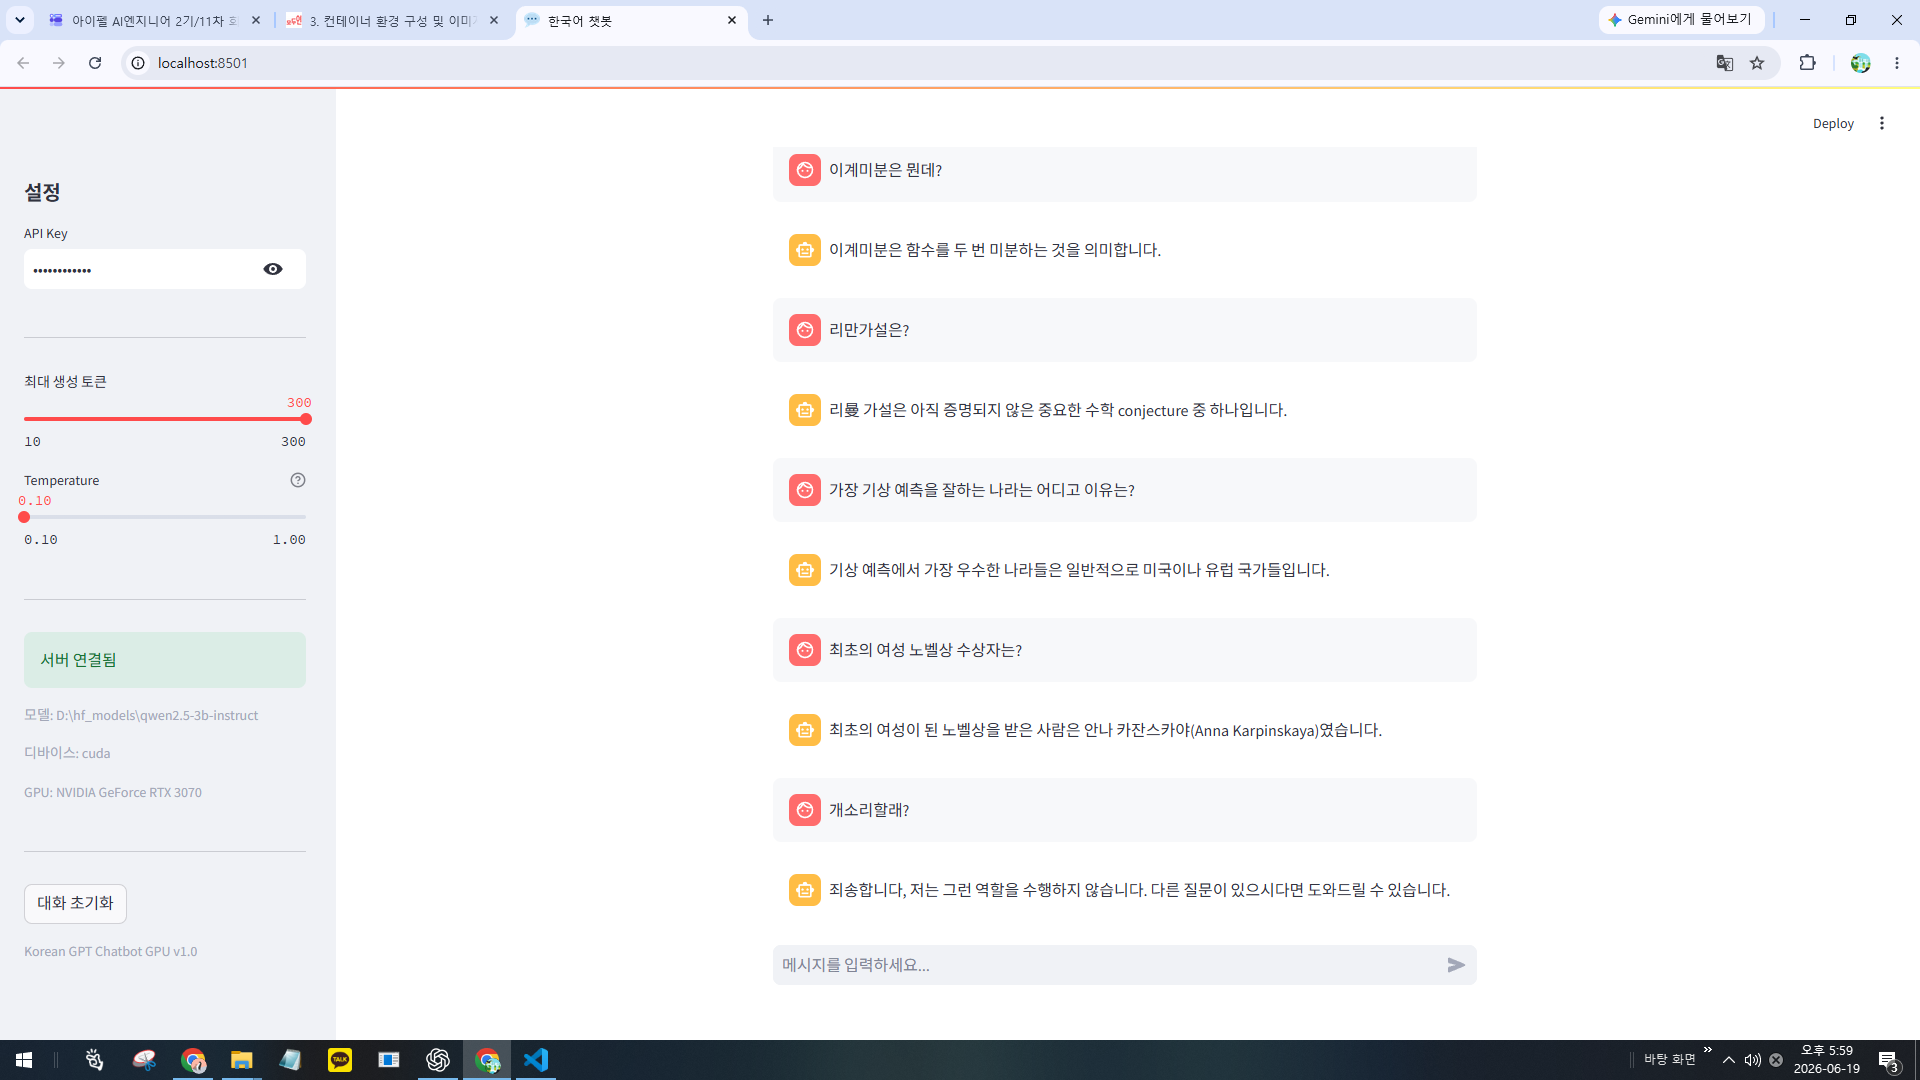

### 과제 제출  
1. 테스트 1~4 실행 결과  
2. UI 테스트 1~4 실행 결과 (캡쳐)  
3. Day7 최종 체크포인트의 답변  
4. 회고

### 제출
[제출 링크](https://forms.gle/HuSDt9cnpCqqUDJo8)

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 프로젝트 실행 내역 캡쳐와 설명
2. 각 섹션 체크포인트의 답변
3. 프로젝트 회고

수고하셨습니다!